# BME 574 — the same network, handed to PyTorch
### 80-minute demo · Project 3, companion to the from-scratch notebook

You have already written a dense network in NumPy: the forward pass, the backward pass, and the
training loop, about forty lines. This notebook does **the same job on the same data**, and the
point is not that PyTorch is shorter. It is to see exactly which of those forty lines the framework
replaces, and what it hands you in return.

**Do the NumPy notebook first.** Everything here is measured against it, and the single most
important cell in this notebook compares your own hand-derived gradient with the one PyTorch
computes.

| | Time | Part |
|---|---|---|
| 0 | 0:00 | Same data, same bar — and tensors |
| 1 | 0:08 | **Autograd, against your own backward pass** |
| 2 | 0:24 | A training loop with autograd but no framework |
| 3 | 0:36 | `nn.Module`, `nn.Linear`, `CrossEntropyLoss` |
| 4 | 0:48 | Optimisers and `DataLoader` |
| 5 | 0:56 | Four ways to break it silently |
| 6 | 1:08 | Overfitting, early stopping, weight decay |
| 7 | 1:16 | Device, saving, and the per-class result |

**Requirements:** `torch`, plus the `numpy` / `pandas` / `matplotlib` / `scikit-learn` you already
have, and `data/fetal_health_ctg.csv` next to this notebook. CPU is fine — everything here runs in
about three seconds.

> **Instructor note.** Cells marked **▶ TYPE THIS LIVE** are worth writing out. Part 1 is the
> reason this notebook exists; if you are short on time, cut Part 4 and shorten Part 6, but do not
> cut Part 1.

---
# 0 · Same data, same bar — and tensors
**0:00 – 0:08**

In [1]:
# If this raises ImportError, install the CPU build:
#     pip install torch --index-url https://download.pytorch.org/whl/cpu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

print('torch', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('using device:', DEVICE)

torch.manual_seed(0)
plt.rcParams.update({'font.size': 10, 'figure.dpi': 110})
np.set_printoptions(precision=4, suppress=True)

torch 2.14.0+cu130
CUDA available: False
using device: cpu


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('data/fetal_health_ctg.csv')
X_all = df.drop(columns='fetal_health').to_numpy(float)
y_all = df['fetal_health'].to_numpy(int) - 1
CLASSES = ['Normal', 'Suspect', 'Pathologic']

Xtr_raw, Xte_raw, ytr, yte = train_test_split(
    X_all, y_all, test_size=0.25, random_state=0, stratify=y_all)

# same rule as always: the scaler is a model parameter, fit on training rows only
scaler = StandardScaler().fit(Xtr_raw)
Xtr, Xte = scaler.transform(Xtr_raw), scaler.transform(Xte_raw)

majority = float((yte == 0).mean())
print('train', Xtr.shape, '  test', Xte.shape)
print('majority baseline  %.3f' % majority)

train (1594, 21)   test (532, 21)
majority baseline  0.778


### Arrays become tensors

A `torch.Tensor` is a NumPy array that additionally knows how to differentiate itself and which
device it lives on. Almost every NumPy expression you wrote carries over unchanged.

Two details that matter and will bite otherwise:

- **dtype.** NumPy defaults to `float64`; PyTorch defaults to `float32`, and every layer expects
  `float32` unless told otherwise. Passing a `float64` tensor into an `nn.Linear` raises a dtype
  error. We use `float32` for training and `float64` only in Part 1, where we need the extra
  digits to make a point.
- **labels are `long`.** `CrossEntropyLoss` wants integer class indices, not one-hot rows. No
  `onehot()` function anywhere in this notebook.

In [3]:
Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
Xte_t = torch.tensor(Xte, dtype=torch.float32)
ytr_t = torch.tensor(ytr, dtype=torch.long)
yte_t = torch.tensor(yte, dtype=torch.long)

print('Xtr_t', tuple(Xtr_t.shape), Xtr_t.dtype)
print('ytr_t', tuple(ytr_t.shape), ytr_t.dtype, ' <- class indices, not one-hot')
print()
print('NumPy habits that survive unchanged:')
print('  Xtr_t[:2, :4]           ->', Xtr_t[:2, :4].numpy().round(3))
print('  Xtr_t.mean(0)[:4]       ->', Xtr_t.mean(0)[:4].numpy().round(6))
print('  (Xtr_t @ Xtr_t.T).shape ->', tuple((Xtr_t @ Xtr_t.T).shape))
print()
print('and the two that do not:')
print('  torch.tensor(Xtr).dtype ->', torch.tensor(Xtr).dtype, ' (float64 - layers reject it)')
print('  Xtr_t.dtype             ->', Xtr_t.dtype, ' (what nn.Linear expects)')

Xtr_t (1594, 21) torch.float32
ytr_t (1594,) torch.int64  <- class indices, not one-hot

NumPy habits that survive unchanged:
  Xtr_t[:2, :4]           -> [[ 0.661 -0.055 -0.204  1.256]
 [-0.669  0.984 -0.204  0.914]]
  Xtr_t.mean(0)[:4]       -> [-0. -0.  0. -0.]
  (Xtr_t @ Xtr_t.T).shape -> (1594, 1594)

and the two that do not:
  torch.tensor(Xtr).dtype -> torch.float64  (float64 - layers reject it)
  Xtr_t.dtype             -> torch.float32  (what nn.Linear expects)


---
# 1 · Autograd, checked against your own backward pass
**0:08 – 0:24**

This is the part that matters.

In the NumPy notebook you derived the backward pass by hand and validated it against finite
differences, getting agreement near `1e-7`. Now we build the **same forward pass** out of torch
operations, call `loss.backward()`, and compare the result to your hand-derived gradient on
**identical parameters**.

The question to hold in mind: is autograd a better approximation, or is it the same computation?

### First, your NumPy code — unchanged from the from-scratch notebook

In [4]:
def init_params(sizes, seed=0, out_scale=0.1):
    r = np.random.default_rng(seed)
    params, last = [], len(sizes) - 2
    for i, (n_in, n_out) in enumerate(zip(sizes[:-1], sizes[1:])):
        sd = np.sqrt(2.0 / n_in) * (out_scale if i == last else 1.0)
        params.append([r.normal(0.0, sd, size=(n_in, n_out)), np.zeros(n_out)])
    return params


def forward_np(params, X):
    A, last = [X], len(params) - 1
    for i, (W, b) in enumerate(params):
        Z = A[-1] @ W + b
        A.append(Z if i == last else np.maximum(Z, 0.0))
    return A


def softmax_np(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)


def onehot(y, n_classes=3):
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1.0
    return Y


def cross_entropy_np(logits, Y):
    return -float((Y * np.log(softmax_np(logits) + 1e-12)).sum()) / len(Y)


def backward_np(params, activations, Y):
    N, grads = len(Y), [None] * len(params)
    D = (softmax_np(activations[-1]) - Y) / N          # the punchline from the lecture
    for i in range(len(params) - 1, -1, -1):
        grads[i] = [activations[i].T @ D, D.sum(axis=0)]
        if i > 0:
            D = (D @ params[i][0].T) * (activations[i] > 0)
    return grads


P = init_params([21, 32, 3])
print('parameters:', sum(W.size + b.size for W, b in P))

parameters: 803


### ▶ TYPE THIS LIVE — the same forward pass, in torch

Three things to narrate while typing:

- `requires_grad=True` is the entire opt-in. It tells PyTorch to record every operation this tensor
  takes part in, so the chain of operations can be walked backwards later.
- The forward pass is **the same expression** as the NumPy one. `@` is still matmul, `torch.relu`
  is still `max(0, z)`. Nothing has been abstracted away yet.
- `float64` here on purpose: we are about to measure a difference near the limit of floating-point
  precision, and `float32` would hide it in rounding noise.

In [5]:
BATCH = 64
Xb_np, yb_np = Xtr[:BATCH], ytr[:BATCH]

# exactly the same parameters, as torch tensors that will record their history
W1 = torch.tensor(P[0][0], requires_grad=True)
b1 = torch.tensor(P[0][1], requires_grad=True)
W2 = torch.tensor(P[1][0], requires_grad=True)
b2 = torch.tensor(P[1][1], requires_grad=True)

Xb = torch.tensor(Xb_np, dtype=torch.float64)
yb = torch.tensor(yb_np, dtype=torch.long)

hidden = torch.relu(Xb @ W1 + b1)
logits = hidden @ W2 + b2
loss = nn.functional.cross_entropy(logits, yb)      # log-softmax + NLL, fused

print('loss (torch)  %.12f' % loss.item())
print('loss (numpy)  %.12f' % cross_entropy_np(forward_np(P, Xb_np)[-1], onehot(yb_np)))

loss (torch)  1.162615874100
loss (numpy)  1.162615874097


### The graph PyTorch built while you were writing the forward pass

Every tensor produced from a `requires_grad` tensor carries a `grad_fn`: the operation that made
it, and a pointer to its inputs. That chain is the computational graph — the same boxes-and-arrows
picture from the lecture, constructed automatically.

In [6]:
print('logits.requires_grad :', logits.requires_grad)
print('loss.grad_fn         :', loss.grad_fn)
print()
print('walking the graph backwards from the loss:')
node, chain = loss.grad_fn, []
while node is not None:
    chain.append(type(node).__name__)
    nxt = [f[0] for f in node.next_functions if f[0] is not None]
    node = nxt[0] if nxt else None
print('   ' + '\n   <- '.join(chain))
print()
print('Compare to the lecture diagram: loss <- softmax <- linear <- ... <- input.')
print('AccumulateGrad is where a leaf parameter collects its gradient.')

logits.requires_grad : True
loss.grad_fn         : <NllLossBackward0 object at 0x7f1dec6c25f0>

walking the graph backwards from the loss:
   NllLossBackward0
   <- LogSoftmaxBackward0
   <- AddBackward0
   <- MmBackward0
   <- ReluBackward0
   <- AddBackward0
   <- MmBackward0
   <- AccumulateGrad

Compare to the lecture diagram: loss <- softmax <- linear <- ... <- input.
AccumulateGrad is where a leaf parameter collects its gradient.


### ▶ TYPE THIS LIVE — one line replaces your entire backward function

In [7]:
loss.backward()

G = backward_np(P, forward_np(P, Xb_np), onehot(yb_np))   # your hand-derived gradients

print('%-4s %16s %16s %14s' % ('', 'max |difference|', 'relative', 'your grad max'))
worst = 0.0
for name, t, g in [('W1', W1, G[0][0]), ('b1', b1, G[0][1]),
                   ('W2', W2, G[1][0]), ('b2', b2, G[1][1])]:
    d = np.abs(t.grad.numpy() - g).max()
    rel = d / max(np.abs(g).max(), 1e-30)
    worst = max(worst, rel)
    print('%-4s %16.3e %16.3e %14.6f' % (name, d, rel, np.abs(g).max()))

print()
print('WORST RELATIVE DIFFERENCE  %.3e' % worst)
print()
print('finite differences vs your hand-derived gradient, in the NumPy notebook:  ~1e-07')
print('autograd            vs your hand-derived gradient, here:                  %.0e' % worst)

     max |difference|         relative  your grad max
W1          1.735e-18        1.357e-16       0.012787
b1          1.735e-18        8.169e-17       0.021236
W2          1.110e-16        2.055e-16       0.540306
b2          2.220e-16        4.479e-16       0.495713

WORST RELATIVE DIFFERENCE  4.479e-16

finite differences vs your hand-derived gradient, in the NumPy notebook:  ~1e-07
autograd            vs your hand-derived gradient, here:                  4e-16


### Read those two numbers again

They are eleven orders of magnitude apart, and the difference is the whole idea.

- Finite differences **approximate** the derivative by evaluating the loss twice and dividing.
  The `1e-7` is approximation error, and it is the best a central difference can do in double
  precision — too small a step and subtraction cancels, too large and the curvature shows.
- Autograd does not approximate anything. It applies the same chain rule you applied, in the same
  order, using the same local derivatives. The residual is **floating-point rounding**, around
  `1e-16` — the two computations are algebraically identical and differ only because the
  multiplications happened in a different sequence.

So: PyTorch did not compute the gradient a better way. It computed *your* gradient, and the only
thing it saved you was the derivation.

> **Instructor note.** This is the bridge to the automatic differentiation lecture. The mechanism
> that walks that graph — reverse-mode AD — is exactly what Prof. Strey covers separately. What
> this notebook establishes is that there is no magic in it: the answer is identical to the one
> the class derived on the board, to fifteen decimal places.
>
> Worth asking: *"if autograd is exact, why did we bother with the finite-difference check?"*
> Because the finite-difference check validates code a human wrote. Autograd has nothing to
> validate — it cannot get the chain rule wrong, only the forward pass can be wrong.

### One more thing about `.backward()`: gradients accumulate

In [8]:
W1.grad.zero_()
loss1 = nn.functional.cross_entropy(torch.relu(Xb @ W1 + b1) @ W2 + b2, yb)
loss1.backward()
after_one = W1.grad.abs().max().item()

for _ in range(2):                                # two more backward calls, no zeroing
    lossk = nn.functional.cross_entropy(torch.relu(Xb @ W1 + b1) @ W2 + b2, yb)
    lossk.backward()
after_three = W1.grad.abs().max().item()

print('after 1 backward call   %.6f' % after_one)
print('after 3 backward calls  %.6f' % after_three)
print('ratio                   %.2f   <- they SUMMED' % (after_three / after_one))
print()
print('This is deliberate (it is how you accumulate over several batches),')
print('and it is why every training loop calls zero_grad() first. Forget it and')
print('your effective learning rate grows without bound.')

after 1 backward call   0.012787
after 3 backward calls  0.038361
ratio                   3.00   <- they SUMMED

This is deliberate (it is how you accumulate over several batches),
and it is why every training loop calls zero_grad() first. Forget it and
your effective learning rate grows without bound.


---
# 2 · A training loop with autograd but no framework
**0:24 – 0:36**

Before reaching for `nn.Module`, train the parameters we already have. This is your NumPy loop with
exactly one line changed — the backward pass — so it is easy to see what autograd bought and what
it did not.

In [9]:
def train_raw(epochs=60, lr=0.05, batch=64, seed=0):
    params = init_params([21, 32, 3], seed)
    W1 = torch.tensor(params[0][0], dtype=torch.float32, requires_grad=True)
    b1 = torch.tensor(params[0][1], dtype=torch.float32, requires_grad=True)
    W2 = torch.tensor(params[1][0], dtype=torch.float32, requires_grad=True)
    b2 = torch.tensor(params[1][1], dtype=torch.float32, requires_grad=True)
    theta = [W1, b1, W2, b2]
    lossfn = nn.CrossEntropyLoss()
    g = torch.Generator().manual_seed(seed + 100)

    def net(X):
        return torch.relu(X @ W1 + b1) @ W2 + b2

    for ep in range(epochs):
        order = torch.randperm(len(Xtr_t), generator=g)
        for s in range(0, len(Xtr_t), batch):
            idx = order[s:s + batch]

            for p in theta:                        # 1. clear last step's gradients
                if p.grad is not None:
                    p.grad.zero_()
            lossfn(net(Xtr_t[idx]), ytr_t[idx]).backward()   # 2. forward + backward
            with torch.no_grad():                  # 3. update, untracked
                for p in theta:
                    p -= lr * p.grad
    return net, theta


net_raw, theta_raw = train_raw()
with torch.no_grad():
    acc = (net_raw(Xte_t).argmax(1) == yte_t).double().mean().item()
print('hand-held parameters, autograd backward:  test accuracy %.3f' % acc)
print('majority baseline:                        %.3f' % majority)

hand-held parameters, autograd backward:  test accuracy 0.915
majority baseline:                        0.778


**Ask the room:** *why is the update wrapped in `torch.no_grad()`?*

Because `p -= lr * p.grad` is itself an operation on a tensor that requires grad. Without the
context manager, PyTorch records the update as part of the graph, the graph grows every step, and
memory climbs until the process dies. `no_grad()` says: run this arithmetic, record nothing.

The same context manager is why evaluation is wrapped in it later — you are not going to
differentiate the test loss, so there is no reason to pay for the bookkeeping.

---
# 3 · `nn.Module`, `nn.Linear`, `CrossEntropyLoss`
**0:36 – 0:48**

Now the idiomatic version. Everything below is bookkeeping — PyTorch is holding the parameters,
naming them, and iterating them for you. No new mathematics appears.

In [10]:
def make_model(hidden=(32,), seed=0, out_scale=0.1):
    torch.manual_seed(seed)
    sizes = [21] + list(hidden) + [3]
    layers, last = [], len(sizes) - 2
    for i, (n_in, n_out) in enumerate(zip(sizes[:-1], sizes[1:])):
        lin = nn.Linear(n_in, n_out)
        with torch.no_grad():                      # same He init, same shrunk output layer
            lin.weight.normal_(0.0, (2.0 / n_in) ** 0.5 * (out_scale if i == last else 1.0))
            lin.bias.zero_()
        layers.append(lin)
        if i != last:
            layers.append(nn.ReLU())
    return nn.Sequential(*layers)


model = make_model()
print(model)
print()
for name, p in model.named_parameters():
    print('  %-10s %-12s %5d values' % (name, str(tuple(p.shape)), p.numel()))
print()
print('total parameters:', sum(p.numel() for p in model.parameters()))

Sequential(
  (0): Linear(in_features=21, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=3, bias=True)
)

  0.weight   (32, 21)       672 values
  0.bias     (32,)           32 values
  2.weight   (3, 32)         96 values
  2.bias     (3,)             3 values

total parameters: 803


`nn.Linear(21, 32)` stores its weight as **(out, in) = (32, 21)** and computes `x @ W.T + b`. Your
NumPy code stored `W` as `(in, out)` and computed `x @ W + b`. Same layer, transposed convention —
and worth pointing at, because it is the first thing that confuses someone porting code between the
two.

The parameter count is 803, exactly as counted in the lecture.

### The training loop, idiomatically

In [11]:
def evaluate(model, X, y, lossfn):
    model.eval()                                   # switch off dropout / batch-norm training mode
    with torch.no_grad():                          # no graph, no gradient bookkeeping
        z = model(X)
        return lossfn(z, y).item(), (z.argmax(1) == y).double().mean().item()


def train(model, epochs=60, lr=0.05, batch=64, seed=0, optimiser='sgd',
          weight_decay=0.0, Xa=None, ya=None, Xv=None, yv=None, verbose=True):
    Xa = Xtr_t if Xa is None else Xa
    ya = ytr_t if ya is None else ya
    Xv = Xte_t if Xv is None else Xv
    yv = yte_t if yv is None else yv

    opt = (torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
           if optimiser == 'sgd' else
           torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay))
    lossfn = nn.CrossEntropyLoss()
    g = torch.Generator().manual_seed(seed + 100)
    history = []

    for ep in range(epochs):
        model.train()
        order = torch.randperm(len(Xa), generator=g)
        for s in range(0, len(Xa), batch):
            idx = order[s:s + batch]
            opt.zero_grad()
            loss = lossfn(model(Xa[idx]), ya[idx])
            loss.backward()
            opt.step()

        tr_l, tr_a = evaluate(model, Xa, ya, lossfn)
        va_l, va_a = evaluate(model, Xv, yv, lossfn)
        history.append((tr_l, va_l, tr_a, va_a))
        if verbose and (ep < 3 or (ep + 1) % 15 == 0):
            print('epoch %3d   train loss %.4f  acc %.3f    |    test loss %.4f  acc %.3f'
                  % (ep + 1, tr_l, tr_a, va_l, va_a))
    return np.array(history)


model = make_model()
hist = train(model)

epoch   1   train loss 0.5074  acc 0.831    |    test loss 0.5016  acc 0.844
epoch   2   train loss 0.4173  acc 0.858    |    test loss 0.4085  acc 0.876
epoch   3   train loss 0.3729  acc 0.861    |    test loss 0.3650  acc 0.885


epoch  15   train loss 0.2565  acc 0.898    |    test loss 0.2722  acc 0.898


epoch  30   train loss 0.2212  acc 0.908    |    test loss 0.2540  acc 0.900


epoch  45   train loss 0.2009  acc 0.913    |    test loss 0.2394  acc 0.906


epoch  60   train loss 0.1868  acc 0.922    |    test loss 0.2350  acc 0.910


In [12]:
from sklearn.metrics import f1_score

model.eval()
with torch.no_grad():
    pred = model(Xte_t).argmax(1).numpy()

print('%-38s %9s %9s' % ('', 'accuracy', 'macro-F1'))
print('%-38s %9.3f %9.3f' % ('always predict Normal', majority,
                             f1_score(yte, np.zeros_like(yte), average='macro')))
print('%-38s %9.3f %9.3f' % ('your NumPy network (from-scratch)', 0.917, 0.831))
print('%-38s %9.3f %9.3f' % ('this PyTorch network, plain SGD', (pred == yte).mean(),
                             f1_score(yte, pred, average='macro')))
print()
print('Same architecture, same initialisation scheme, same optimiser, same data.')
print('The small difference is the random number generator: torch shuffles batches')
print('with its own RNG, so the two runs see the batches in a different order.')

                                        accuracy  macro-F1
always predict Normal                      0.778     0.292
your NumPy network (from-scratch)          0.917     0.831
this PyTorch network, plain SGD            0.910     0.819

Same architecture, same initialisation scheme, same optimiser, same data.
The small difference is the random number generator: torch shuffles batches
with its own RNG, so the two runs see the batches in a different order.


---
# 4 · Optimisers and `DataLoader`
**0:48 – 0:56**

The first thing most people actually gain from a framework is not the autograd — you have seen that
it just reproduces your own derivative — it is everything around it.

In [13]:
import time

results = {}
for label, kw in [('SGD, lr=0.05', dict(optimiser='sgd', lr=0.05)),
                  ('SGD, lr=0.5', dict(optimiser='sgd', lr=0.5)),
                  ('Adam, lr=0.01', dict(optimiser='adam', lr=0.01)),
                  ('Adam, lr=0.001', dict(optimiser='adam', lr=0.001))]:
    t0 = time.time()
    m = make_model()
    h = train(m, epochs=60, verbose=False, **kw)
    results[label] = h
    print('%-16s  final train %.3f   test %.3f   (%.1fs)'
          % (label, h[-1, 2], h[-1, 3], time.time() - t0))

SGD, lr=0.05      final train 0.922   test 0.910   (1.0s)


SGD, lr=0.5       final train 0.967   test 0.925   (1.0s)


Adam, lr=0.01     final train 0.984   test 0.934   (1.7s)


Adam, lr=0.001    final train 0.920   test 0.912   (1.5s)


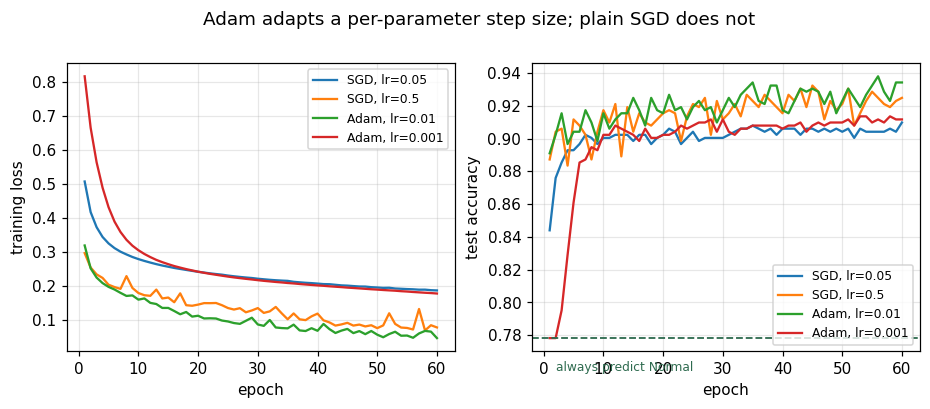

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for label, h in results.items():
    ep = np.arange(1, len(h) + 1)
    ax[0].plot(ep, h[:, 0], label=label)
    ax[1].plot(ep, h[:, 3], label=label)
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('training loss'); ax[0].grid(alpha=.3)
ax[0].legend(fontsize=8)
ax[1].axhline(majority, color='#2E6B4F', ls='--', lw=1.2)
ax[1].text(2, majority - 0.02, 'always predict Normal', color='#2E6B4F', fontsize=8)
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('test accuracy'); ax[1].grid(alpha=.3)
ax[1].legend(fontsize=8, loc='lower right')
fig.suptitle('Adam adapts a per-parameter step size; plain SGD does not', y=1.02)
plt.show()

Adam keeps a running estimate of the mean and variance of each parameter's gradient and scales that
parameter's step accordingly. In Project 2, Levenberg–Marquardt did something with the same spirit
through λ — it adapted the step to the local geometry. Plain gradient descent gave that up when we
moved to 803 parameters; Adam buys part of it back cheaply.

**It is not free.** Adam reaches a lower training loss faster, which also means it reaches the
overfitting regime faster. Watch the gap, not the training curve.

### `Dataset` and `DataLoader`

Our data fits in memory, so the manual `randperm` slicing is fine. The moment it does not — images
on disk, a multi-gigabyte signal archive — you want batching, shuffling, and parallel loading
handled for you. The interface is worth seeing once.

In [15]:
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(Xtr_t, ytr_t)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

print('dataset length :', len(train_ds))
print('batches / epoch:', len(train_dl))
xb, yb_ = next(iter(train_dl))
print('one batch      :', tuple(xb.shape), tuple(yb_.shape))
print()

m = make_model()
opt = torch.optim.SGD(m.parameters(), lr=0.05)
lossfn = nn.CrossEntropyLoss()
for _ in range(60):
    m.train()
    for xb, yb_ in train_dl:                       # the entire epoch, batched and shuffled
        opt.zero_grad()
        lossfn(m(xb), yb_).backward()
        opt.step()

print('trained through a DataLoader:  test accuracy %.3f' % evaluate(m, Xte_t, yte_t, lossfn)[1])

dataset length : 1594
batches / epoch: 25
one batch      : (64, 21) (64,)



trained through a DataLoader:  test accuracy 0.908


---
# 5 · Four ways to break it silently
**0:56 – 1:08**

Every one of these runs without an exception, and every one of them costs you accuracy or lies to
you about it. They are the reason a framework is not automatically safer than forty lines of NumPy.

### 1. Applying softmax before `CrossEntropyLoss`

`nn.CrossEntropyLoss` expects **logits**. It applies log-softmax internally, for numerical
stability. Hand it probabilities and it softmaxes them a second time.

In [16]:
def train_quick(pre_softmax, epochs=60, lr=0.05, seed=0):
    m = make_model(seed=seed)
    opt = torch.optim.SGD(m.parameters(), lr=lr)
    lossfn = nn.CrossEntropyLoss()
    g = torch.Generator().manual_seed(seed + 100)
    for _ in range(epochs):
        m.train()
        order = torch.randperm(len(Xtr_t), generator=g)
        for s in range(0, len(Xtr_t), 64):
            idx = order[s:s + 64]
            opt.zero_grad()
            z = m(Xtr_t[idx])
            lossfn(torch.softmax(z, 1) if pre_softmax else z, ytr_t[idx]).backward()
            opt.step()
    return evaluate(m, Xte_t, yte_t, lossfn)[1]


m0 = make_model()
z0 = m0(Xtr_t[:256])
print('CrossEntropyLoss(logits)           %.4f   <- correct'
      % nn.CrossEntropyLoss()(z0, ytr_t[:256]).item())
print('CrossEntropyLoss(softmax(logits))  %.4f   <- wrong, and barely different'
      % nn.CrossEntropyLoss()(torch.softmax(z0, 1), ytr_t[:256]).item())
print()
print('correct      test accuracy %.3f' % train_quick(False))
print('softmaxed    test accuracy %.3f' % train_quick(True))
print()
print('The loss barely moves, nothing errors, and the model is several points worse.')

CrossEntropyLoss(logits)           1.0956   <- correct
CrossEntropyLoss(softmax(logits))  1.0970   <- wrong, and barely different



correct      test accuracy 0.910


softmaxed    test accuracy 0.853

The loss barely moves, nothing errors, and the model is several points worse.


### 2. Forgetting `optimizer.zero_grad()`

We measured the mechanism in Part 1 — gradients sum. Here is what it does to training.

In [17]:
def train_nozero(epochs=30, lr=0.05, seed=0):
    m = make_model(seed=seed)
    opt = torch.optim.SGD(m.parameters(), lr=lr)
    lossfn = nn.CrossEntropyLoss()
    g = torch.Generator().manual_seed(seed + 100)
    for _ in range(epochs):
        m.train()
        order = torch.randperm(len(Xtr_t), generator=g)
        for s in range(0, len(Xtr_t), 64):
            idx = order[s:s + 64]
            lossfn(m(Xtr_t[idx]), ytr_t[idx]).backward()    # <- no zero_grad
            opt.step()
    return evaluate(m, Xte_t, yte_t, lossfn)


m = make_model()
ok_loss, ok_acc = train(m, epochs=30, verbose=False)[-1, [1, 3]]
bad_loss, bad_acc = train_nozero()
print('with zero_grad()     test loss %.4f   acc %.3f' % (ok_loss, ok_acc))
print('without zero_grad()  test loss %.4f   acc %.3f' % (bad_loss, bad_acc))

with zero_grad()     test loss 0.2540   acc 0.900
without zero_grad()  test loss 18.2334   acc 0.829


### 3. Forgetting `model.eval()`

Our model has no dropout or batch normalisation, so `train()` and `eval()` do nothing here — which
is exactly why this bug survives into projects that do have them. Add one dropout layer and the
difference is immediate.

In [18]:
drop_model = nn.Sequential(nn.Linear(21, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, 3))
batch = Xte_t[:8]

drop_model.train()
a, b = drop_model(batch), drop_model(batch)
print('model.train():  two passes over the SAME batch differ by %.4f' % (a - b).abs().max().item())

drop_model.eval()
c, d = drop_model(batch), drop_model(batch)
print('model.eval() :  two passes over the SAME batch differ by %.4f' % (c - d).abs().max().item())
print()
print('Reporting a test score in train() mode means reporting a randomly corrupted model.')
print('It reads as a slightly worse result, not as a bug - which is why it survives.')

model.train():  two passes over the SAME batch differ by 0.8570
model.eval() :  two passes over the SAME batch differ by 0.0000

Reporting a test score in train() mode means reporting a randomly corrupted model.
It reads as a slightly worse result, not as a bug - which is why it survives.


### 4. Evaluating without `torch.no_grad()`

No wrong answer here — just a graph built for every evaluation batch and immediately thrown away,
holding on to every intermediate activation until it is. On a large validation set that is the
difference between fitting in GPU memory and an out-of-memory error.

In [19]:
big = Xtr_t.repeat(200, 1)                         # ~319k rows
print('evaluating', big.shape[0], 'rows two ways\n')

z_graph = model(big)
with torch.no_grad():
    z_free = model(big)

print('%-16s requires_grad=%-7s grad_fn=%s'
      % ('with graph', z_graph.requires_grad, type(z_graph.grad_fn).__name__))
print('%-16s requires_grad=%-7s grad_fn=%s'
      % ('with no_grad()', z_free.requires_grad, z_free.grad_fn))
print()
print('The first result is still attached to a graph, which is holding every')
print('intermediate activation for those 319k rows so they could be differentiated.')
print('The second holds nothing at all - which is exactly the point:')
try:
    z_free.sum().backward()
except RuntimeError as e:
    print('   z_free.sum().backward()  ->  RuntimeError:', str(e)[:68])
print()
print('On this CPU the speed difference is noise. The memory difference is not,')
print('and it is what runs you out of GPU memory during validation.')

evaluating 318800 rows two ways

with graph       requires_grad=True    grad_fn=AddmmBackward0
with no_grad()   requires_grad=False   grad_fn=None

The first result is still attached to a graph, which is holding every
intermediate activation for those 319k rows so they could be differentiated.
The second holds nothing at all - which is exactly the point:
   z_free.sum().backward()  ->  RuntimeError: element 0 of tensors does not require grad and does not have a grad_

On this CPU the speed difference is noise. The memory difference is not,
and it is what runs you out of GPU memory during validation.


---
# 6 · Overfitting, early stopping, weight decay
**1:08 – 1:16**

Same experiment as the from-scratch notebook: starve it of data, give it far too many parameters,
and watch the loss and the accuracy disagree.

This time we do it properly — with a **validation split carved out of the training data**, so the
stopping epoch is chosen without ever looking at the test set.

In [20]:
rng = np.random.default_rng(0)
perm = rng.permutation(len(Xtr_t))
sub, val = perm[:200], perm[200:400]               # 200 to train on, 200 held out to watch

Xsub, ysub = Xtr_t[sub], ytr_t[sub]
Xval, yval = Xtr_t[val], ytr_t[val]
print('train on %d rows, validate on %d, test set untouched (%d rows)'
      % (len(sub), len(val), len(Xte_t)))

big_model = make_model((256, 256))
print('parameters:', sum(p.numel() for p in big_model.parameters()), 'for', len(sub), 'samples')

hb = train(big_model, epochs=300, Xa=Xsub, ya=ysub, Xv=Xval, yv=yval, verbose=False)
best = int(hb[:, 1].argmin())

lossfn = nn.CrossEntropyLoss()
print()
print('train loss %.5f   train accuracy %.3f  <- memorised all 200' % (hb[-1, 0], hb[-1, 2]))
print()
print('VALIDATION loss best  %.4f at epoch %d' % (hb[best, 1], best + 1))
print('VALIDATION loss final %.4f at epoch %d   (%.1f%% worse)'
      % (hb[-1, 1], len(hb), 100 * (hb[-1, 1] / hb[best, 1] - 1)))
print('VALIDATION accuracy   best %.3f -> final %.3f   <- essentially unchanged'
      % (hb[best, 3], hb[-1, 3]))

train on 200 rows, validate on 200, test set untouched (532 rows)
parameters: 72195 for 200 samples



train loss 0.00546   train accuracy 1.000  <- memorised all 200

VALIDATION loss best  0.1977 at epoch 26
VALIDATION loss final 0.2881 at epoch 300   (45.8% worse)
VALIDATION accuracy   best 0.920 -> final 0.910   <- essentially unchanged


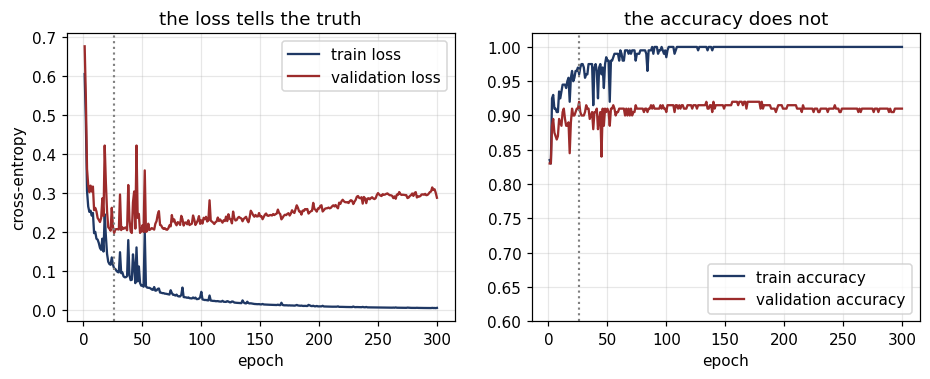

In [21]:
ep = np.arange(1, len(hb) + 1)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(ep, hb[:, 0], color='#1F3864', label='train loss')
ax[0].plot(ep, hb[:, 1], color='#9C2B2B', label='validation loss')
ax[0].axvline(best + 1, color='grey', ls=':', lw=1.4)
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('cross-entropy')
ax[0].legend(); ax[0].grid(alpha=.3); ax[0].set_title('the loss tells the truth')
ax[1].plot(ep, hb[:, 2], color='#1F3864', label='train accuracy')
ax[1].plot(ep, hb[:, 3], color='#9C2B2B', label='validation accuracy')
ax[1].axvline(best + 1, color='grey', ls=':', lw=1.4)
ax[1].set_ylim(0.6, 1.02); ax[1].set_xlabel('epoch')
ax[1].legend(loc='lower right'); ax[1].grid(alpha=.3)
ax[1].set_title('the accuracy does not')
plt.show()

The same finding as in NumPy: **the loss rots while the accuracy stands still.** The network keeps
its answers and becomes more confident in them, including the wrong ones. For a screening tool that
is the dangerous failure, and accuracy cannot see it.

### Early stopping, done honestly

Keep a copy of the parameters at the validation minimum, and restore it at the end. `state_dict()`
is how PyTorch hands you the parameters as a plain dictionary.

In [22]:
import copy

m = make_model((256, 256))
opt = torch.optim.SGD(m.parameters(), lr=0.05)
lossfn = nn.CrossEntropyLoss()
g = torch.Generator().manual_seed(100)

best_loss, best_state, best_ep = float('inf'), None, -1
for ep_i in range(300):
    m.train()
    order = torch.randperm(len(Xsub), generator=g)
    for s in range(0, len(Xsub), 64):
        idx = order[s:s + 64]
        opt.zero_grad(); lossfn(m(Xsub[idx]), ysub[idx]).backward(); opt.step()
    v_loss, _ = evaluate(m, Xval, yval, lossfn)
    if v_loss < best_loss:
        best_loss, best_ep = v_loss, ep_i
        best_state = copy.deepcopy(m.state_dict())     # deepcopy: state_dict shares storage

print('trained 300 epochs; best validation loss %.4f, reached at epoch %d'
      % (best_loss, best_ep + 1))
print()
print('TEST scores, looked at exactly once, at the very end:')
print('  final-epoch weights      loss %.4f   acc %.3f' % evaluate(m, Xte_t, yte_t, lossfn))
m.load_state_dict(best_state)
print('  early-stopped weights    loss %.4f   acc %.3f' % evaluate(m, Xte_t, yte_t, lossfn))
print()

m_wd = make_model((256, 256))
h_wd = train(m_wd, epochs=300, weight_decay=1e-2, Xa=Xsub, ya=ysub,
             Xv=Xval, yv=yval, verbose=False)
print('  weight_decay=1e-2, 300ep loss %.4f   acc %.3f' % evaluate(m_wd, Xte_t, yte_t, lossfn))
print()
print('weight_decay in the optimiser IS the L2 penalty from the lecture -')
print('one keyword instead of adding lambda*theta to every gradient by hand.')

trained 300 epochs; best validation loss 0.1977, reached at epoch 26

TEST scores, looked at exactly once, at the very end:
  final-epoch weights      loss 0.5613   acc 0.893
  early-stopped weights    loss 0.3574   acc 0.895



  weight_decay=1e-2, 300ep loss 0.3753   acc 0.889

weight_decay in the optimiser IS the L2 penalty from the lecture -
one keyword instead of adding lambda*theta to every gradient by hand.


---
# 7 · Device, saving, and the result that matters
**1:16 – 1:24**

In [23]:
# the device idiom: move the model and the batch, never one without the other
model_dev = make_model().to(DEVICE)
xb = Xtr_t[:8].to(DEVICE)
print('model on %s, batch on %s -> output on %s'
      % (next(model_dev.parameters()).device, xb.device, model_dev(xb).device))
print()
print('A mismatch raises "Expected all tensors to be on the same device".')
print('It is the single most common first-GPU error, and the fix is always')
print('the same: .to(DEVICE) on the model once, on every batch as it is drawn.')
print()

# saving: the state_dict, not the model object
torch.save(model.state_dict(), 'ctg_model.pt')
reloaded = make_model()
reloaded.load_state_dict(torch.load('ctg_model.pt', weights_only=True))
reloaded.eval()
with torch.no_grad():
    same = torch.equal(reloaded(Xte_t), model(Xte_t))
print('saved and reloaded; predictions identical:', same)
print()
print('Save the state_dict, not the model object. Pickling the object ties the')
print('file to your class definitions and your directory layout; the state_dict')
print('is just named tensors and will still load in two years.')

model on cpu, batch on cpu -> output on cpu

A mismatch raises "Expected all tensors to be on the same device".
It is the single most common first-GPU error, and the fix is always
the same: .to(DEVICE) on the model once, on every batch as it is drawn.

saved and reloaded; predictions identical: True

Save the state_dict, not the model object. Pickling the object ties the
file to your class definitions and your directory layout; the state_dict
is just named tensors and will still load in two years.


### The sting, unchanged

One number is not a result.

In [24]:
from sklearn.metrics import confusion_matrix, recall_score

model.eval()
with torch.no_grad():
    pred = model(Xte_t).argmax(1).numpy()

print('overall accuracy %.3f' % (pred == yte).mean())
print()
print('%-14s %10s %10s' % ('class', 'n in test', 'recall'))
for c, nm in enumerate(CLASSES):
    print('%-14s %10d %10.3f'
          % (nm, (yte == c).sum(), recall_score(yte, pred, labels=[c], average='macro')))
print()
print(pd.DataFrame(confusion_matrix(yte, pred), index=CLASSES, columns=CLASSES))

overall accuracy 0.910

class           n in test     recall
Normal                414      0.959
Suspect                74      0.716
Pathologic             44      0.773

            Normal  Suspect  Pathologic
Normal         397       15           2
Suspect         14       53           7
Pathologic       4        6          34


In [25]:
# the fix, and its price - in PyTorch it is one argument
counts = np.bincount(ytr)
weights = torch.tensor(counts.sum() / (3 * counts), dtype=torch.float32)
print('class weights', weights.numpy().round(2), '\n')

m_w = make_model()
opt = torch.optim.SGD(m_w.parameters(), lr=0.05)
lossfn_w = nn.CrossEntropyLoss(weight=weights)        # <- the entire change
g = torch.Generator().manual_seed(100)
for _ in range(60):
    m_w.train()
    order = torch.randperm(len(Xtr_t), generator=g)
    for s in range(0, len(Xtr_t), 64):
        idx = order[s:s + 64]
        opt.zero_grad(); lossfn_w(m_w(Xtr_t[idx]), ytr_t[idx]).backward(); opt.step()

m_w.eval()
with torch.no_grad():
    pred_w = m_w(Xte_t).argmax(1).numpy()

print('%-22s %10s %10s %10s %10s' % ('', 'accuracy', 'Normal', 'Suspect', 'Patholog'))
for nm, pp in [('unweighted', pred), ('inverse-frequency', pred_w)]:
    rec = [recall_score(yte, pp, labels=[c], average='macro') for c in range(3)]
    print('%-22s %10.3f %10.3f %10.3f %10.3f' % (nm, (pp == yte).mean(), *rec))

class weights [0.43 2.4  4.03] 



                         accuracy     Normal    Suspect   Patholog
unweighted                  0.910      0.959      0.716      0.773
inverse-frequency           0.870      0.882      0.838      0.818


Pathologic and Suspect recall go up; overall accuracy goes down. There is no setting of this model
where you get both, and which trade you want is a clinical judgement rather than a technical one.

PyTorch made the change one keyword long. It did not make the decision any easier.

---

## What the framework actually gave us

| You wrote it in NumPy | PyTorch replaced it with | Was it the hard part? |
|---|---|---|
| the backward pass, derived by hand | `loss.backward()` | The derivation, yes. The result is **identical to 1e-16.** |
| the gradient check | nothing — there is nothing to check | It validated *your* code |
| the parameter update loop | `optimizer.step()` | No, but Adam is a real gain |
| batching and shuffling by hand | `DataLoader` | Not at this size; yes at scale |
| an L2 term added to every gradient | `weight_decay=...` | No |
| moving to a GPU: not possible | `.to(device)` | This one is the real prize |

The honest summary: the framework did not understand the problem better than you did. It removed
the derivation, the bookkeeping and the hardware, and it added four new ways to be silently wrong.
Every number in this notebook — the baseline, the network, the overfitting, the per-class
breakdown — is the one you already produced in forty lines of NumPy.

**Next:** automatic differentiation — how `loss.backward()` walks the graph you saw in Part 1, and
why it costs about the same as the forward pass.